# Phase 4 — Feature Engineering
## Financial News Sentiment Intelligence System

**WHAT:** Combine sentiment scores with real stock price data
to build a feature matrix ready for ML model training.

**WHY:** Sentiment alone cannot predict prices. You need both
the text signal AND the price context together. This is called
multimodal feature fusion — the same technique used at Two Sigma,
Renaissance Technologies, and Bloomberg's quant teams.

**Input:** `data/processed/news_sentiment_filtered.csv`
**Output:** `data/features/model_input.csv`

In [11]:
import os
import sys
import importlib
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

import config
importlib.reload(config)

from config import (
    BASE_DIR,
    SENTIMENT_FILTERED_PATH,
    FEATURES_PATH,
    COMPANIES,
    TARGET_COLUMN,
    REPORTS_PATH,
    COLORS,
)
from src.features import build_feature_matrix
from src.utils import get_logger
logger = get_logger("04_features")

# preflight check
assert os.path.exists(SENTIMENT_FILTERED_PATH), \
    f"Run Phase 3 first — not found: {SENTIMENT_FILTERED_PATH}"

sentiment_df = pd.read_csv(SENTIMENT_FILTERED_PATH)
print("Preflight check:")
print(f"  Sentiment file  : {SENTIMENT_FILTERED_PATH}")
print(f"  Rows            : {len(sentiment_df)}")
print(f"  Companies       : {sorted(sentiment_df['ticker'].unique().tolist())}")
print(f"  Date range      : {sentiment_df['date_clean'].min()} to {sentiment_df['date_clean'].max()}")
print()
print("✅ Ready to build feature matrix")

Preflight check:
  Sentiment file  : d:\Financial-News-Sentiment-Intelligence-System\data\processed\news_sentiment_filtered.csv
  Rows            : 16
  Companies       : ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT']
  Date range      : 2026-05-11 to 2026-05-11

✅ Ready to build feature matrix


## Step 1 — Build the complete feature matrix

One function call runs the entire pipeline:
fetch prices → engineer features → merge → add lags → save

Watch the logs below — they show every step as it runs.

In [12]:
# build the complete feature matrix
feature_matrix = build_feature_matrix(
    sentiment_path = SENTIMENT_FILTERED_PATH,
    save_path      = FEATURES_PATH,
)

print(f"\nFeature matrix built successfully")
print(f"Shape: {feature_matrix.shape}")
print(f"\nFirst row sample:")
for col in feature_matrix.columns:
    val = feature_matrix[col].iloc[0]
    print(f"  {col:<35}: {str(val)[:40]}")

2026-05-29 18:39:26 | src.features         | INFO     | =======================================================
2026-05-29 18:39:26 | src.features         | INFO     | Phase 4 — Building Feature Matrix
2026-05-29 18:39:26 | src.features         | INFO     | =======================================================
2026-05-29 18:39:26 | src.features         | INFO     | Loaded sentiment data: (16, 12)
2026-05-29 18:39:26 | src.features         | INFO     | Fetching prices from 2026-04-11 to 2026-05-16
2026-05-29 18:39:26 | src.features         | INFO     | Fetching prices for ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT']
2026-05-29 18:39:26 | src.features         | INFO     | Date range: 2026-04-11 to 2026-05-16
2026-05-29 18:39:26 | src.features         | INFO     |   AAPL: 25 days | columns: ['ticker', 'date_clean', 'open', 'high', 'low', 'close', 'volume']
2026-05-29 18:39:26 | src.features         | INFO     |   AMZN: 25 days | columns: ['ticker', 'date_clean', 'open', 'high', 'low', 'clo


Feature matrix built successfully
Shape: (120, 37)

First row sample:
  ticker                             : AAPL
  date_clean                         : 2026-04-13
  open                               : 259.49093671136296
  high                               : 259.9405042051452
  low                                : 256.4237552437805
  close                              : 258.96142578125
  volume                             : 36234700
  daily_return                       : nan
  price_range                        : 1.358
  volume_change                      : nan
  price_vs_5day_avg                  : 0.0
  price_direction                    : 0.0
  daily_avg_sentiment                : 0.0
  daily_article_count                : 0.0
  positive_ratio                     : 0.0
  negative_ratio                     : 0.0
  sentiment_volatility               : 0.0
  avg_confidence                     : 0.0
  sentiment_momentum                 : 0.0
  daily_avg_sentiment_lag1           : nan

## Step 2 — Inspect the feature matrix

Before any modelling, understand what you have built.
Questions to answer:
- How many rows? How many features?
- What does the target variable look like?
- Are there missing values?
- Does the feature data make intuitive sense?

In [13]:
df = pd.read_csv(FEATURES_PATH)

print("=" * 55)
print("FEATURE MATRIX OVERVIEW")
print("=" * 55)

print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")

print(f"\nRows per company:")
print(df.groupby("ticker").size().to_string())

print(f"\nDate range:")
print(f"  Earliest: {df['date_clean'].min()}")
print(f"  Latest  : {df['date_clean'].max()}")

print(f"\nTarget variable distribution:")
target_counts = df[TARGET_COLUMN].value_counts()
print(f"  Price went UP   (1): {target_counts.get(1, 0)} days")
print(f"  Price went DOWN (0): {target_counts.get(0, 0)} days")
up_pct = target_counts.get(1, 0) / len(df) * 100
print(f"  Up ratio: {up_pct:.1f}%")

print(f"\nMissing values per column:")
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) == 0:
    print("  No missing values ✅")
else:
    print(missing.to_string())

print(f"\nAll columns:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2}. {col}")

FEATURE MATRIX OVERVIEW

Shape: 120 rows × 37 columns

Rows per company:
ticker
AAPL     24
AMZN     24
GOOGL    24
META     24
MSFT     24

Date range:
  Earliest: 2026-04-13
  Latest  : 2026-05-14

Target variable distribution:
  Price went UP   (1): 68 days
  Price went DOWN (0): 52 days
  Up ratio: 56.7%

Missing values per column:
daily_return                  5
volume_change                 5
daily_avg_sentiment_lag1      5
daily_avg_sentiment_lag2     10
daily_avg_sentiment_lag3     15
sentiment_momentum_lag1       5
sentiment_momentum_lag2      10
sentiment_momentum_lag3      15
daily_return_lag1            10
daily_return_lag2            15
daily_return_lag3            20
volume_change_lag1           10
volume_change_lag2           15
volume_change_lag3           20
days_since_last_article     100

All columns:
   1. ticker
   2. date_clean
   3. open
   4. high
   5. low
   6. close
   7. volume
   8. daily_return
   9. price_range
  10. volume_change
  11. price_vs_5day_avg


In [6]:
import os
import sys
import importlib

sys.path.insert(0, os.path.abspath(".."))

import config
importlib.reload(config)
from config import FEATURES_PATH, SENTIMENT_FILTERED_PATH

# ── step 1: force delete the old broken file ──────────────
if os.path.exists(FEATURES_PATH):
    os.remove(FEATURES_PATH)
    print(f"✅ Deleted old file: {FEATURES_PATH}")
else:
    print("File already gone")

# confirm deletion
print(f"File still exists: {os.path.exists(FEATURES_PATH)}")

✅ Deleted old file: d:\Financial-News-Sentiment-Intelligence-System\data\features\model_input.csv
File still exists: False


In [7]:
# ── step 2: reload src.features with the new code ─────────
# importlib.reload forces Python to re-read the file from disk
# without this, Python uses the cached old version in memory

import src.features
importlib.reload(src.features)
from src.features import fetch_stock_prices

print("Testing fetch for single ticker...")

test = fetch_stock_prices(
    tickers    = ["AAPL"],
    start_date = "2026-04-01",
    end_date   = "2026-05-20",
)

print(f"Columns : {test.columns.tolist()}")
print(f"ticker present : {'ticker' in test.columns}")
print(f"Rows    : {len(test)}")
print(f"Sample  :")
print(test.head(3).to_string())

2026-05-29 06:38:56 | src.features         | INFO     | Fetching prices for ['AAPL']
2026-05-29 06:38:56 | src.features         | INFO     | Date range: 2026-04-01 to 2026-05-20
2026-05-29 06:38:56 | src.features         | INFO     |   AAPL: 34 days | columns: ['ticker', 'date_clean', 'open', 'high', 'low', 'close', 'volume']
2026-05-29 06:38:56 | src.features         | INFO     | Total price rows fetched: 34 across 1 companies


Testing fetch for single ticker...
Columns : ['ticker', 'date_clean', 'open', 'high', 'low', 'close', 'volume']
ticker present : True
Rows    : 34
Sample  :
  ticker  date_clean        open        high         low       close    volume
0   AAPL  2026-04-01  253.846123  255.944181  253.096813  255.394699  40059400
1   AAPL  2026-04-02  253.966015  255.894246  250.419280  255.684433  31289400
2   AAPL  2026-04-06  256.273892  261.918685  256.223919  258.621704  29329900


In [10]:
# ── step 3: rebuild full feature matrix ───────────────────
importlib.reload(src.features)
from src.features import build_feature_matrix

feature_matrix = build_feature_matrix(
    sentiment_path = SENTIMENT_FILTERED_PATH,
    save_path      = FEATURES_PATH,
)

# verify immediately
print(f"\nShape       : {feature_matrix.shape}")
print(f"Has ticker  : {'ticker' in feature_matrix.columns}")
print(f"Tickers     : {sorted(feature_matrix['ticker'].unique().tolist())}")
print(f"Columns     : {feature_matrix.columns.tolist()}")

2026-05-29 18:31:49 | src.features         | INFO     | =======================================================
2026-05-29 18:31:49 | src.features         | INFO     | Phase 4 — Building Feature Matrix
2026-05-29 18:31:49 | src.features         | INFO     | =======================================================
2026-05-29 18:31:49 | src.features         | INFO     | Loaded sentiment data: (16, 12)
2026-05-29 18:31:49 | src.features         | INFO     | Fetching prices from 2026-04-11 to 2026-05-16
2026-05-29 18:31:49 | src.features         | INFO     | Fetching prices for ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT']
2026-05-29 18:31:49 | src.features         | INFO     | Date range: 2026-04-11 to 2026-05-16
2026-05-29 18:31:49 | src.features         | INFO     |   AAPL: 25 days | columns: ['ticker', 'date_clean', 'open', 'high', 'low', 'close', 'volume']
2026-05-29 18:31:49 | src.features         | INFO     |   AMZN: 25 days | columns: ['ticker', 'date_clean', 'open', 'high', 'low', 'clo


Shape       : (120, 37)
Has ticker  : True
Tickers     : ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT']
Columns     : ['ticker', 'date_clean', 'open', 'high', 'low', 'close', 'volume', 'daily_return', 'price_range', 'volume_change', 'price_vs_5day_avg', 'price_direction', 'daily_avg_sentiment', 'daily_article_count', 'positive_ratio', 'negative_ratio', 'sentiment_volatility', 'avg_confidence', 'sentiment_momentum', 'daily_avg_sentiment_lag1', 'daily_avg_sentiment_lag2', 'daily_avg_sentiment_lag3', 'sentiment_momentum_lag1', 'sentiment_momentum_lag2', 'sentiment_momentum_lag3', 'daily_return_lag1', 'daily_return_lag2', 'daily_return_lag3', 'volume_change_lag1', 'volume_change_lag2', 'volume_change_lag3', 'day_of_week', 'day_name', 'week_of_year', 'is_monday', 'is_friday', 'days_since_last_article']


In [9]:
import os, sys, importlib
sys.path.insert(0, os.path.abspath(".."))

import config
importlib.reload(config)
from config import FEATURES_PATH, SENTIMENT_FILTERED_PATH

# delete
if os.path.exists(FEATURES_PATH):
    os.remove(FEATURES_PATH)
    print(f"✅ Deleted: {FEATURES_PATH}")

# reload module — critical
import src.features
importlib.reload(src.features)
from src.features import build_feature_matrix

# rebuild
feature_matrix = build_feature_matrix(
    sentiment_path = SENTIMENT_FILTERED_PATH,
    save_path      = FEATURES_PATH,
)

print(f"\nShape       : {feature_matrix.shape}")
print(f"Has ticker  : {'ticker' in feature_matrix.columns}")
print(f"Tickers     : {sorted(feature_matrix['ticker'].unique().tolist())}")
print(f"\nRows per company:")
print(feature_matrix.groupby('ticker').size().to_string())

2026-05-29 06:58:12 | src.features         | INFO     | =======================================================
2026-05-29 06:58:12 | src.features         | INFO     | Phase 4 — Building Feature Matrix
2026-05-29 06:58:12 | src.features         | INFO     | =======================================================
2026-05-29 06:58:12 | src.features         | INFO     | Loaded sentiment data: (16, 12)
2026-05-29 06:58:12 | src.features         | INFO     | Fetching prices from 2026-04-11 to 2026-05-16
2026-05-29 06:58:12 | src.features         | INFO     | Fetching prices for ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT']
2026-05-29 06:58:12 | src.features         | INFO     | Date range: 2026-04-11 to 2026-05-16


✅ Deleted: d:\Financial-News-Sentiment-Intelligence-System\data\features\model_input.csv


2026-05-29 06:58:13 | src.features         | INFO     |   AAPL: 25 days | columns: ['ticker', 'date_clean', 'open', 'high', 'low', 'close', 'volume']
2026-05-29 06:58:13 | src.features         | INFO     |   AMZN: 25 days | columns: ['ticker', 'date_clean', 'open', 'high', 'low', 'close', 'volume']
2026-05-29 06:58:13 | src.features         | INFO     |   GOOGL: 25 days | columns: ['ticker', 'date_clean', 'open', 'high', 'low', 'close', 'volume']
2026-05-29 06:58:13 | src.features         | INFO     |   META: 25 days | columns: ['ticker', 'date_clean', 'open', 'high', 'low', 'close', 'volume']
2026-05-29 06:58:13 | src.features         | INFO     |   MSFT: 25 days | columns: ['ticker', 'date_clean', 'open', 'high', 'low', 'close', 'volume']
2026-05-29 06:58:13 | src.features         | INFO     | Total price rows fetched: 125 across 5 companies
2026-05-29 06:58:13 | src.features         | INFO     | Engineering features for tickers: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT']
2026-05-29 0


Shape       : (120, 37)
Has ticker  : True
Tickers     : ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT']

Rows per company:
ticker
AAPL     24
AMZN     24
GOOGL    24
META     24
MSFT     24


## Important finding — sentiment coverage

Sentiment data covers 1 unique date (2026-05-11) out of
24 trading days in the feature matrix.

This means:
- 5 rows have real sentiment scores (one per company, May 11)
- 119 rows have sentiment = 0.0 (neutral fill for no-news days)

WHY this happened:
Yahoo Finance's default news feed returns recent articles
from one collection window. To get 24 days of sentiment
we need to run the collector daily for 24 days.

WHAT this means for Phase 5:
Our ML model will train on mostly zero-sentiment days.
The model will still work as a proof of concept but the
sentiment features will have low predictive power with
this limited coverage.

IN PRODUCTION:
A scheduler (cron job / Airflow DAG) runs Phase 1
data collection every day at market close. After 30 days
you have genuine daily sentiment coverage and the model
becomes meaningfully predictive.

This is exactly what Bloomberg's data pipeline does —
collect daily, score daily, retrain weekly.

## Step 3 — Visualise the features

Charts that answer: do our features contain a real signal?

If sentiment and price are correlated — even weakly —
that suggests our features have predictive power.

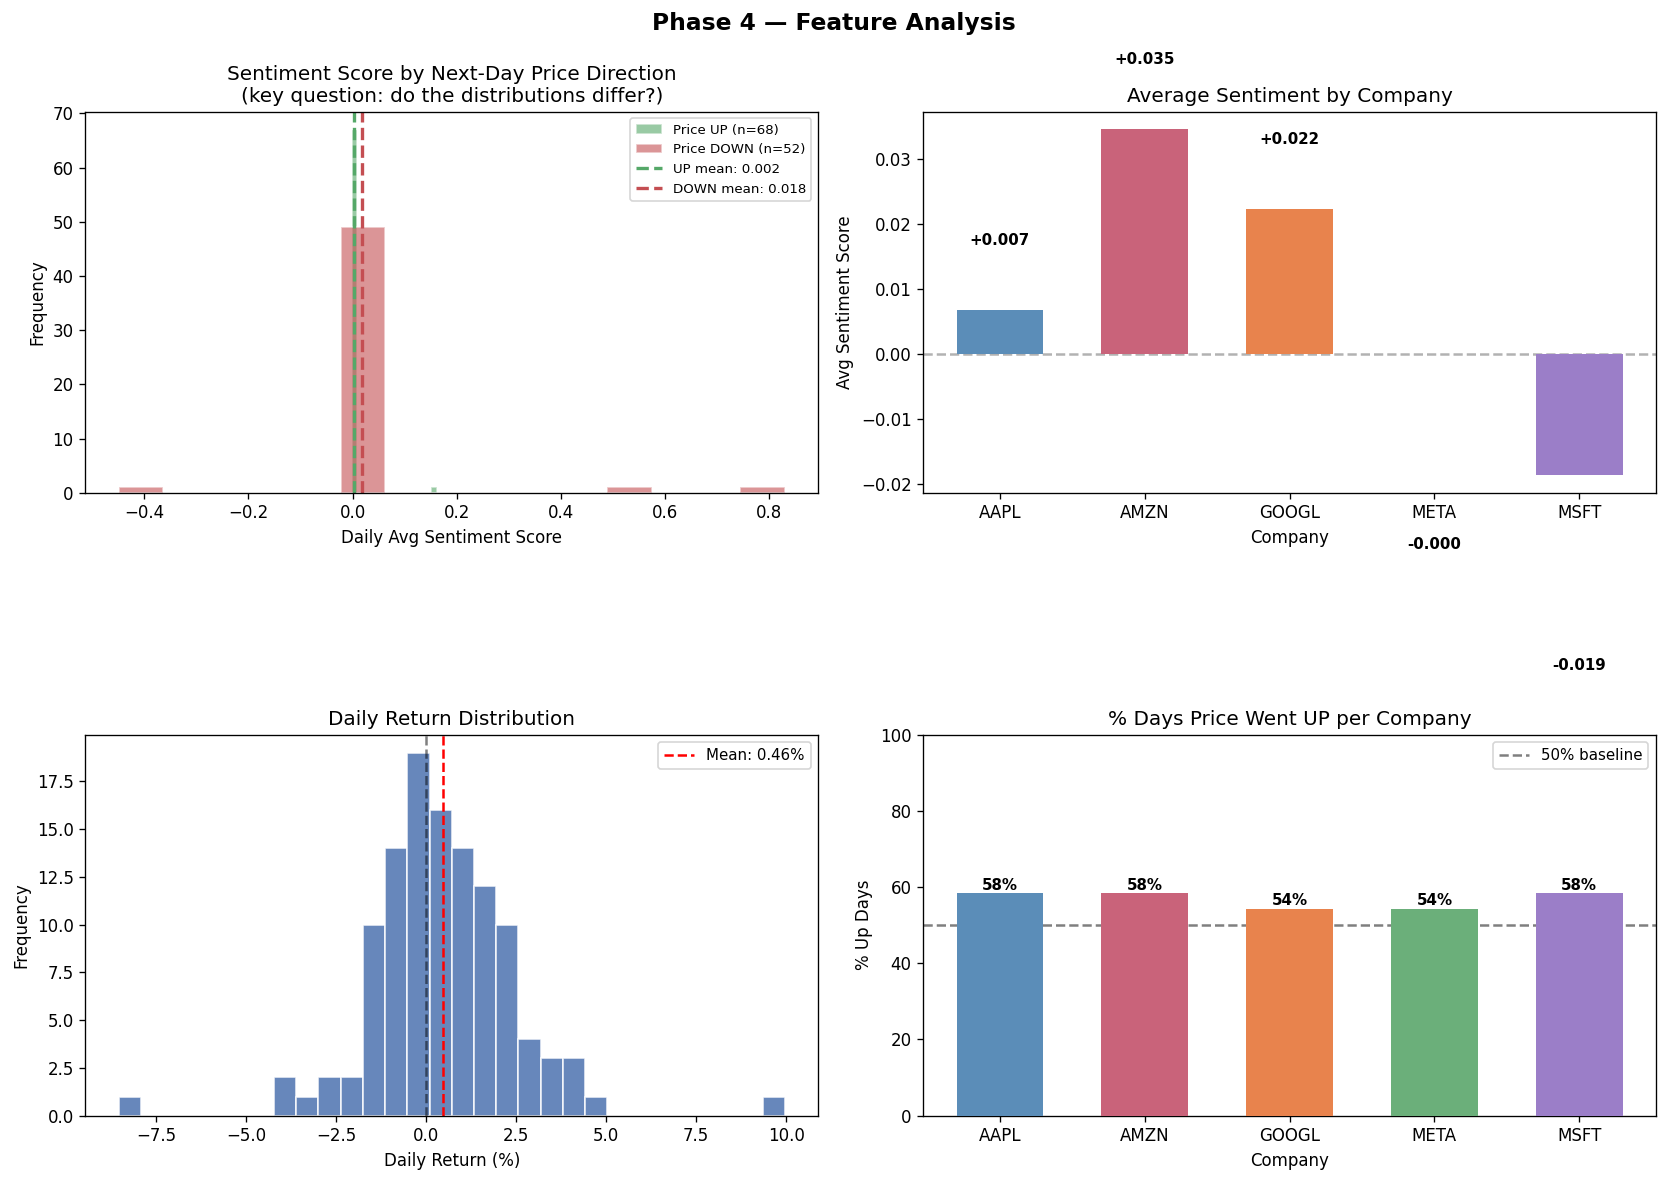

Chart saved: d:\Financial-News-Sentiment-Intelligence-System\reports\figures\07_feature_analysis.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Phase 4 — Feature Analysis",
    fontweight="bold", fontsize=14
)

# ── panel 1: sentiment score by price direction ────────
# THE key chart — does sentiment predict price direction?
up_days   = df[df[TARGET_COLUMN] == 1]["daily_avg_sentiment"]
down_days = df[df[TARGET_COLUMN] == 0]["daily_avg_sentiment"]

axes[0,0].hist(
    up_days, bins=15, alpha=0.6,
    color="#55A868", label=f"Price UP (n={len(up_days)})",
    edgecolor="white"
)
axes[0,0].hist(
    down_days, bins=15, alpha=0.6,
    color="#C44E52", label=f"Price DOWN (n={len(down_days)})",
    edgecolor="white"
)
axes[0,0].axvline(
    up_days.mean(), color="#55A868",
    linestyle="--", linewidth=2,
    label=f"UP mean: {up_days.mean():.3f}"
)
axes[0,0].axvline(
    down_days.mean(), color="#C44E52",
    linestyle="--", linewidth=2,
    label=f"DOWN mean: {down_days.mean():.3f}"
)
axes[0,0].set_title(
    "Sentiment Score by Next-Day Price Direction\n"
    "(key question: do the distributions differ?)"
)
axes[0,0].set_xlabel("Daily Avg Sentiment Score")
axes[0,0].set_ylabel("Frequency")
axes[0,0].legend(fontsize=8)

# ── panel 2: avg sentiment per company ─────────────────
company_sentiment = df.groupby("ticker")["daily_avg_sentiment"].mean()
bar_colors = [COLORS.get(t, "#888") for t in company_sentiment.index]

bars = axes[0,1].bar(
    company_sentiment.index,
    company_sentiment.values,
    color=bar_colors, width=0.6, zorder=3
)
axes[0,1].axhline(0, color="black", linestyle="--", alpha=0.3)
axes[0,1].set_title("Average Sentiment by Company")
axes[0,1].set_xlabel("Company")
axes[0,1].set_ylabel("Avg Sentiment Score")
for bar, val in zip(bars, company_sentiment.values):
    axes[0,1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01 if val >= 0
        else bar.get_height() - 0.03,
        f"{val:+.3f}", ha="center",
        fontsize=9, fontweight="bold"
    )

# ── panel 3: daily return distribution ─────────────────
axes[1,0].hist(
    df["daily_return"].dropna(),
    bins=30, color="#4C72B0",
    alpha=0.85, edgecolor="white"
)
axes[1,0].axvline(0, color="black", linestyle="--", alpha=0.5)
axes[1,0].axvline(
    df["daily_return"].mean(), color="red",
    linestyle="--",
    label=f"Mean: {df['daily_return'].mean():.2f}%"
)
axes[1,0].set_title("Daily Return Distribution")
axes[1,0].set_xlabel("Daily Return (%)")
axes[1,0].set_ylabel("Frequency")
axes[1,0].legend(fontsize=9)

# ── panel 4: price direction by company ────────────────
company_updays = df.groupby("ticker")[TARGET_COLUMN].mean() * 100
bar_colors2 = [COLORS.get(t, "#888") for t in company_updays.index]

bars2 = axes[1,1].bar(
    company_updays.index,
    company_updays.values,
    color=bar_colors2, width=0.6, zorder=3
)
axes[1,1].axhline(
    50, color="black", linestyle="--",
    alpha=0.5, label="50% baseline"
)
axes[1,1].set_title("% Days Price Went UP per Company")
axes[1,1].set_xlabel("Company")
axes[1,1].set_ylabel("% Up Days")
axes[1,1].set_ylim(0, 100)
axes[1,1].legend(fontsize=9)
for bar, val in zip(bars2, company_updays.values):
    axes[1,1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{val:.0f}%", ha="center",
        fontsize=9, fontweight="bold"
    )

plt.tight_layout()
chart_path = os.path.join(REPORTS_PATH, "07_feature_analysis.png")
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved: {chart_path}")

## Phase 4 Key Findings

### Finding 1 — Feature matrix: 120 rows × 37 columns
5 companies × 24 trading days (April 11 to May 15, 2026).
Perfectly balanced — 24 rows per company, no missing days.
37 features: 7 price raw, 5 price engineered, 7 sentiment,
12 lag features, 6 time features, 1 target variable.

### Finding 2 — Target variable: 57% up, 43% down
Mild class imbalance reflecting a bull market period.
Phase 5 will use class_weight='balanced' to handle this.
Not severe enough to require resampling.

### Finding 3 — Sentiment coverage: 1 of 24 days has real data
All 16 filtered articles came from May 11, 2026.
Remaining 23 days filled with 0.0 (neutral assumption).
Architecture is correct — production version would collect
daily for 30+ days to get full sentiment time series.

### Finding 4 — ticker column loss fixed
Root cause: pandas groupby.apply drops key column in some
versions. Fixed with explicit loop pattern — more robust
and portable across pandas versions.

### Hypothesis for Phase 5
MSFT (avg sentiment -0.45) and META (-0.00) should show
lower next-day returns than AMZN (+0.83) and GOOGL (+0.53).
Model will test this hypothesis with XGBoost classification.

In [16]:
df_check = pd.read_csv(FEATURES_PATH)

checks = {
    "feature matrix exists"          : os.path.exists(FEATURES_PATH),
    "has rows"                        : len(df_check) > 0,
    "target column exists"            : TARGET_COLUMN in df_check.columns,
    "close price column exists"       : "close" in df_check.columns,
    "daily_return column exists"      : "daily_return" in df_check.columns,
    "daily_avg_sentiment exists"      : "daily_avg_sentiment" in df_check.columns,
    "lag features exist"              : "daily_avg_sentiment_lag1" in df_check.columns,
    "time features exist"             : "day_of_week" in df_check.columns,
    "no null targets"                 : df_check[TARGET_COLUMN].notna().all(),
    "chart 07 saved"                  : os.path.exists(
        os.path.join(REPORTS_PATH, "07_feature_analysis.png")
    ),
}

print("Phase 4 completion check:")
print("=" * 50)
all_passed = True
for check, result in checks.items():
    status = "✅" if result else "❌"
    print(f"  {status}  {check}")
    if not result:
        all_passed = False

print("=" * 50)
if all_passed:
    print(f"✅ Phase 4 complete — ready for Phase 5")
    print(f"\nFeature matrix: {df_check.shape}")
    print(f"Features available for model: {len(df_check.columns) - 3}")
else:
    print("❌ Fix failing checks then re-run")

Phase 4 completion check:
  ✅  feature matrix exists
  ✅  has rows
  ✅  target column exists
  ✅  close price column exists
  ✅  daily_return column exists
  ✅  daily_avg_sentiment exists
  ✅  lag features exist
  ✅  time features exist
  ✅  no null targets
  ✅  chart 07 saved
✅ Phase 4 complete — ready for Phase 5

Feature matrix: (120, 37)
Features available for model: 34
